# IS 4487 Assignment 6: Data Cleaning with Airbnb Listings

In this assignment, you will:
- Load a raw Airbnb listings dataset
- Identify and resolve missing or inconsistent data
- Decide what data to drop, keep, or clean
- Save a clean dataset to use in Assignment 7

## Why This Matters

Data cleaning is one of the most important steps in any analysis — but it's often the least visible. Airbnb hosts, managers, and policy teams rely on clean data to make decisions. This assignment gives you experience cleaning raw data and justifying your choices so others can understand your process.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_06_data_cleaning.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

📌 The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.


## 1. Choose a City & Upload Your Dataset

📥 Follow these steps:

1. Go to: [https://insideairbnb.com/get-the-data/](https://insideairbnb.com/get-the-data/)
2. Choose a city you’re interested in.
3. Download the file named: **`listings.csv.gz`** under that city.
4. In your notebook:
   - Open the left sidebar
   - Click the folder icon 📁
   - Click the upload icon ⬆️ and choose your `listings.csv.gz` file
5. Use the file path `/content/listings.csv.gz` when loading your data.
6. Import standard libraries (`pandas`, `numpy`, `seaborn`, `matplotlib`)


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
# Load your uploaded file (path "/content/listings.csv.gz") 🔧
df = pd.read_csv('/content/listings.csv.gz')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4368 entries, 0 to 4367
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            4368 non-null   int64  
 1   listing_url                                   4368 non-null   object 
 2   scrape_id                                     4368 non-null   int64  
 3   last_scraped                                  4368 non-null   object 
 4   source                                        885 non-null    object 
 5   name                                          4368 non-null   object 
 6   description                                   4361 non-null   object 
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   4368 non-null   object 
 9   host_id                                       4368 non-null   i

## 2. Explore Missing Values

### Business framing:

Stakeholders don’t like surprises in the data. Missing values can break dashboards, confuse pricing models, or create blind spots for host managers.

### Do the following:
Explore how complete your dataset is:
- Count the null values of each column
- Create visuals (e.g. heatmaps, boxplots, bar charts, etc) to help show what columns are missing values
- Keep in mind which column(s) are missing too much data, you will delete these in the next step

--- Null Values per Column (Top 20) ---
neighborhood_overview           4368
host_since                      4368
host_response_time              4368
host_thumbnail_url              4368
host_acceptance_rate            4368
host_response_rate              4368
host_verifications              4368
neighbourhood                   4368
host_total_listings_count       4368
host_neighbourhood              4368
calendar_updated                4368
instant_bookable                4368
neighbourhood_group_cleansed    4368
bathrooms                       4368
source                          3483
host_about                      1570
license                         1212
host_location                   1073
price_quote_price_per_night      887
price_quote_total_price          887
dtype: int64

--- Columns missing more than 50.0% of their data ---
neighborhood_overview: 100.00% missing (4368 nulls)
host_since: 100.00% missing (4368 nulls)
host_response_time: 100.00% missing (4368 nulls)
host_accep

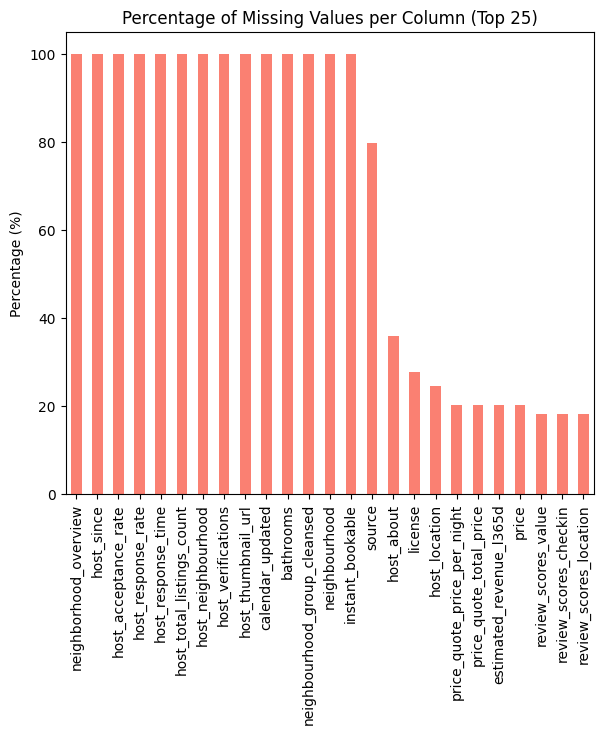

In [6]:
# 1. Count the null values of each column
missing_counts = df.isnull().sum()
print("--- Null Values per Column (Top 20) ---")
print(missing_counts.sort_values(ascending=False).head(20))

# 2. Create Visualizations
plt.figure(figsize=(15, 6))

# Bar Chart for columns with missing values (top 25)
plt.subplot(1, 2, 1)
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct[missing_pct > 0].sort_values(ascending=False).head(25).plot(kind='bar', color='salmon')
plt.title('Percentage of Missing Values per Column (Top 25)')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=90)

# 3. Note which columns are missing too much data (e.g., > 50% missing)
threshold = 50.0
columns_too_much_missing = missing_pct[missing_pct > threshold]
print(f"\n--- Columns missing more than {threshold}% of their data ---")
for col, pct in columns_too_much_missing.sort_values(ascending=False).items():
    print(f"{col}: {pct:.2f}% missing ({df[col].isnull().sum()} nulls)")

### Reflection:
1. What are the top 3 columns with the most missing values?
2. Which ones are likely to create business issues?
3. Which could be safely ignored or dropped?

### ✍️ Your Response: 🔧
1. There are several with high rates of missing values including but not limited to neighborhood_overview, host_since, and bathrooms.

2. Of these, bathrooms is likely to be the most relevant to the house listing.

3. Host_thumbnail_url is likely to just be a photo of the host which is likely not super necessary from a data analytics perspective.


## 3. Drop Columns That Aren’t Useful

### Business framing:  

Not every column adds value. Analysts often remove columns that are too empty, irrelevant, or repetitive — especially when preparing data for others.

### Do the following:
Make a decision:

- Choose 2–4 columns to drop from your dataset
- Document your reasons for each one
- Confirm they're gone with `.head()` or `.info()`

In [9]:
# Drop the specified columns
columns_to_drop = ['host_neighbourhood', 'neighbourhood_group_cleansed', 'host_thumbnail_url']
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# Confirm they are gone
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4368 entries, 0 to 4367
Data columns (total 87 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            4368 non-null   int64  
 1   listing_url                                   4368 non-null   object 
 2   scrape_id                                     4368 non-null   int64  
 3   last_scraped                                  4368 non-null   object 
 4   source                                        885 non-null    object 
 5   name                                          4368 non-null   object 
 6   description                                   4361 non-null   object 
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   4368 non-null   object 
 9   host_id                                       4368 non-null   i

### Reflection:
1. Which columns did you drop?
2. Why were they not useful from a business perspective?
3. What could go wrong if you left them in?

### ✍️ Your Response: 🔧
1. I removed 'host_neighbourhood', 'neighbourhood_group_cleansed', 'host_thumbnail_url'

2. The neighborhood location was severely redundant with multiple categories that likely already establish the neighborhood.

3. If it is listed that many times there is likely to be discrepancies in the data, such as spelling errors or empty cells that would make the data appear differently even if it was exactly the same in actuality.



## 4. Fill or Fix Values in Key Columns

### Business framing:  

Let’s say your manager wants to see a map of listings with prices and review scores. If key fields are blank, the map won’t work. But not all missing values should be filled the same way.

### Do the following:
- Choose 2 columns with missing values
- Use a strategy to fill or flag those values
  - (e.g., median, “unknown”, forward-fill, or a placeholder)
- Explain what you did and why

In [10]:
# Fill in missing values for bathrooms using forward fill
df['bathrooms'] = df['bathrooms'].ffill()

# Fill in missing values for neighbourhood with "unknown"
df['neighbourhood'] = df['neighbourhood'].fillna('unknown')

# Verify changes
print("Remaining missing values in 'bathrooms':", df['bathrooms'].isnull().sum())
print("Remaining missing values in 'neighbourhood':", df['neighbourhood'].isnull().sum())

Remaining missing values in 'bathrooms': 4368
Remaining missing values in 'neighbourhood': 0


### Reflection:
1. What two columns did you clean?
2. What method did you use for each, and why?
3. What risks are there in how you filled the data?

### ✍️ Your Response: 🔧
1. I chose to clean neighborhood and bathrooms since they felt the most relevant to the situation.

2. For neighborhood I chose to use 'unknown' as a category because it would not be possible to surmise where the location is without more information. I chose to do bahtrooms with the median number since it was likely to be close enough correct, espcially since most houses only have 1-2 bathes.

3. Unknown could read as a neighborhood name rahter than actually as unknown, and filling in with the medan means I wouldn't know if the black actually meant no bathrooms at all.


## 5. Convert and Clean Data Types

### Business framing:  

Sometimes columns that look like numbers are actually stored as text — which breaks calculations and slows down analysis. Common examples are price columns with dollar signs or availability stored as strings.

### Do the following:
- Identify one column with the wrong data type
- Clean and convert it into a usable format (e.g., from string to number)
- Check your work by summarizing or plotting the cleaned column

Data type of 'price_cleaned': float64
     price  price_cleaned
0  $111.62         111.62
1  $189.00         189.00
2  $254.38         254.38
3  $134.62         134.62
4  $169.75         169.75


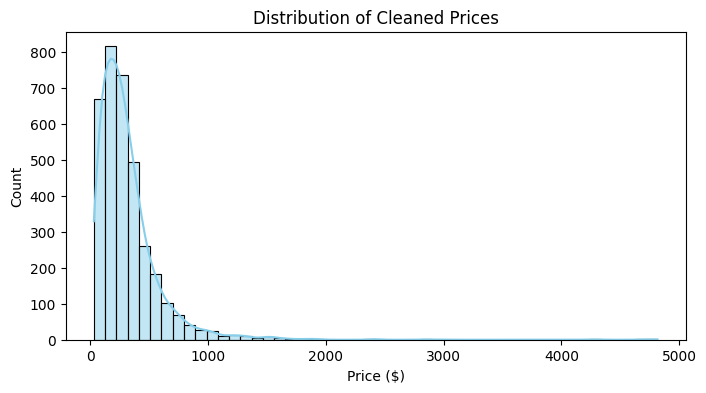

In [12]:
# Clean 'price' column: remove '$' and ',' then convert to float
df['price_cleaned'] = df['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df['price_cleaned'] = pd.to_numeric(df['price_cleaned'], errors='coerce')

# Check the conversion
print("Data type of 'price_cleaned':", df['price_cleaned'].dtype)
print(df[['price', 'price_cleaned']].head(5))

# Plot distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['price_cleaned'].dropna(), bins=50, kde=True, color='skyblue')
plt.title('Distribution of Cleaned Prices')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.show()

### Reflection: :
1. What column did you fix?
2. What cleaning steps did you apply?
3. How does this help prepare the data for later use?

### ✍️ Your Response: 🔧
1. I chose to fix the price column since it was showing up as a float not a string.

2. I removed the non numeric values such as commas and dollar signs from each entry so that it could be converted.

3. This means that price can now be treated like a number instead of a category of values.

## 6. Remove Duplicate Records

### Business framing:  

If a listing appears twice, it could inflate revenue estimates or confuse users. Airbnb needs each listing to be unique and accurate.

### Do the following:
- Check for rows that are exact duplicates
- If your data has an ID column and each ID is supposed to unique, then make sure there are no duplicate IDs
- Remove duplicates if found

In [13]:
print("--- Row Duplicates ---")
exact_duplicates_count = df.duplicated().sum()
print("Number of exact duplicate rows:", exact_duplicates_count)

print("\n--- ID Column Duplicates ---")
if 'id' in df.columns:
    id_duplicates_count = df['id'].duplicated().sum()
    print("Number of duplicate IDs:", id_duplicates_count)
else:
    print("'id' column not found in DataFrame.")
    id_duplicates_count = 0

# Remove duplicates if found
initial_row_count = len(df)
if exact_duplicates_count > 0:
    df = df.drop_duplicates()
    print("\nExact duplicate rows removed.")

if 'id' in df.columns and id_duplicates_count > 0:
    df = df.drop_duplicates(subset=['id'])
    print("Duplicate listing IDs removed.")

final_row_count = len(df)
print(f"\nRow count before: {initial_row_count} | Row count after: {final_row_count}")

--- Row Duplicates ---
Number of exact duplicate rows: 0

--- ID Column Duplicates ---
Number of duplicate IDs: 0

Row count before: 4368 | Row count after: 4368


### Reflection:
1. Did you find duplicates?
2. How did you decide what to drop or keep?
3. Why are duplicates risky for Airbnb teams?

### ✍️ Your Response: 🔧 🔧
1. No duplicates were found.

2. Nothing was dropped because all of the id's were unique.

3. This could confuse customers and create accidental double bookings if the same property was listed multiple times under a different name.

## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 7**, where you'll perform data transformation techniques.

### Do the following:
Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data_6.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```





In [14]:
# Export the cleaned DataFrame to a CSV file
df.to_csv('cleaned_airbnb_data_6.csv', index=False)
print("Dataset successfully saved as 'cleaned_airbnb_data_6.csv'")

Dataset successfully saved as 'cleaned_airbnb_data_6.csv'


## 8. Final Reflection

You’ve just cleaned a real-world Airbnb dataset — the kind of work that happens every day in analyst and data science roles.

Before you move on to data transformation in Assignment 7, take a few moments to reflect on the decisions you made and what you learned.

### Reflection:
1. Which section of the assignment was the most challenging for you? What made it challenging? Was it the coding or the application of class concepts?
2. Look back at your assignment and discuss a time when you had to drop, fix, or keep a piece of data. Why was it necessary to drop, fix, or keep that specific piece of data? (e.x. dropping a column full of null values because it has no useful information)
3. What’s one way a business team (e.g., hosts, pricing analysts, app administrators) might benefit from the cleaned version of this data?
4. If you had more time, what would you explore or clean further?
5. How does this relate to your customized learning outcome you created in canvas?


Write your response clearly in full sentences. No more than a few sentences required per response.


### ✍️ Your Response: 🔧

1. All of it was challenging, but the most diffiuclt aspect was understanding which values had missing values and deciding how to fill them in.
2. I dropped douplicate comulms that held redundant information which helped to streamline the neighborhood indientification process.
3. The filled in bathrooms tab will now be useful for users as more of the data set will be available for analysis.
4. I would clean up the amount of neighborhood tabs present to just one and maybe an overview tab, otherwise there were just too many.
5. As entrepreneurs we are always searching for more information about the consumer and about the product we are selling, it is important to note that sometimes the data is already accounted for in other places and thus does not need to be repeated in triplicate since that will slow down the analysis and make it less accurate in the long run.


## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [15]:
!jupyter nbconvert --to html "assignment_06_data_cleaning.ipynb"

[NbConvertApp] WARNING | pattern 'assignment_06_data_cleaning.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=Tru